# MeanShift Clustering

## Co je MeanShift?

MeanShift je algoritmus pro shluková analýzu založený na detekci hustoty (density-based clustering). Na rozdíl od algoritmů jako K-means, MeanShift nevyžaduje předem specifikovat počet shluků. Místo toho automaticky objevuje "přirozené" shluky v datech na základě hustoty bodů.

### Základní princip:

1. Algoritmus funguje jako iterativní postup, který posune každý datový bod směrem k oblasti s nejvyšší hustotou bodů v jeho okolí
2. Tento proces se opakuje, dokud body nekonvergují ke stacionárním bodům (středy shluků)
3. Body, které konvergují ke stejnému stacionárnímu bodu, jsou považovány za členy stejného shluku

### Klíčové vlastnosti MeanShift:

- **Automatické určení počtu shluků** - algoritmus sám určí počet shluků na základě dat
- **Shluky libovolných tvarů** - schopnost detekovat shluky nepravidelných tvarů
- **Založeno na hustotě** - identifikuje shluky jako oblasti s vysokou hustotou bodů
- **Jediný hlavní parametr** - šířka pásma (bandwidth), která určuje "dosah hledání" hustoty

### Matematický základ:

MeanShift používá jádrový odhad hustoty (kernel density estimation) pro nalezení lokálních maxim hustoty. Pro daný bod $x$ iterativně aktualizuje jeho pozici podle vzorce:

$$x_{t+1} = \frac{\sum_{i=1}^{n} K(\frac{x_i - x_t}{h})x_i}{\sum_{i=1}^{n} K(\frac{x_i - x_t}{h})}$$

kde:
- $K$ je jádrová funkce (nejčastěji Gaussovské jádro)
- $h$ je šířka pásma (bandwidth)
- $x_i$ jsou datové body v okolí bodu $x$

In [1]:
# Import potřebných knihoven
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import MeanShift, estimate_bandwidth, KMeans
from sklearn.datasets import make_blobs, make_moons, load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.neighbors import NearestNeighbors
import time
import pandas as pd

# Nastavení vizuálního stylu
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
np.random.seed(42)

## 1. Základní použití MeanShift

Nejprve vytvoříme syntetická data a ukážeme si základní použití algoritmu MeanShift.

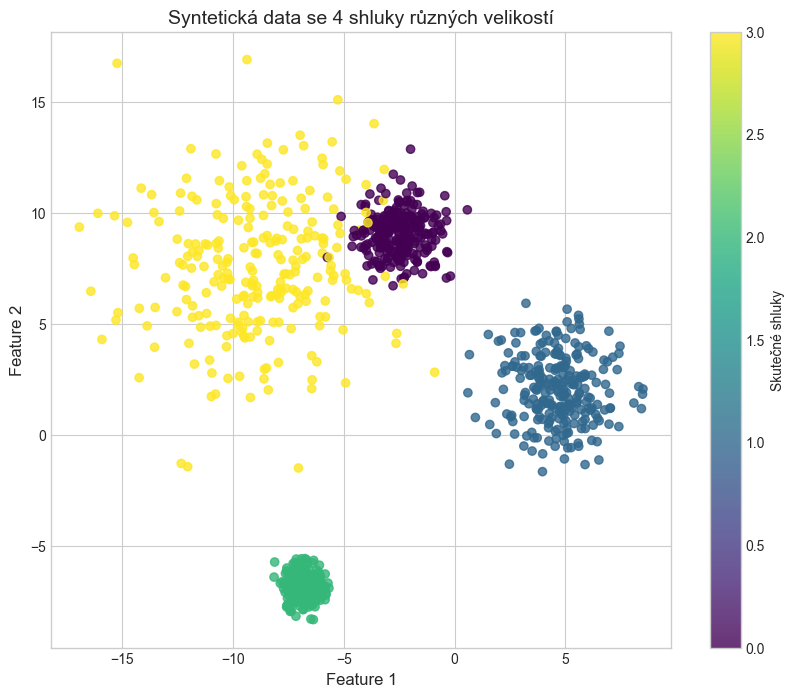

In [2]:
# Vytvoření syntetických dat s různými shluky
n_samples = 1000
X, y_true = make_blobs(n_samples=n_samples, centers=4, cluster_std=[1.0, 1.5, 0.5, 3.0],
                      random_state=42)

# Vykreslení původních dat
plt.figure(figsize=(10, 8))
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', alpha=0.8)
plt.colorbar(label='Skutečné shluky')
plt.title('Syntetická data se 4 shluky různých velikostí', fontsize=14)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.grid(True)
plt.show()

Odhadnutá šířka pásma (bandwidth): 3.233
Počet nalezených shluků: 6
Doba výpočtu: 1.768 sekund


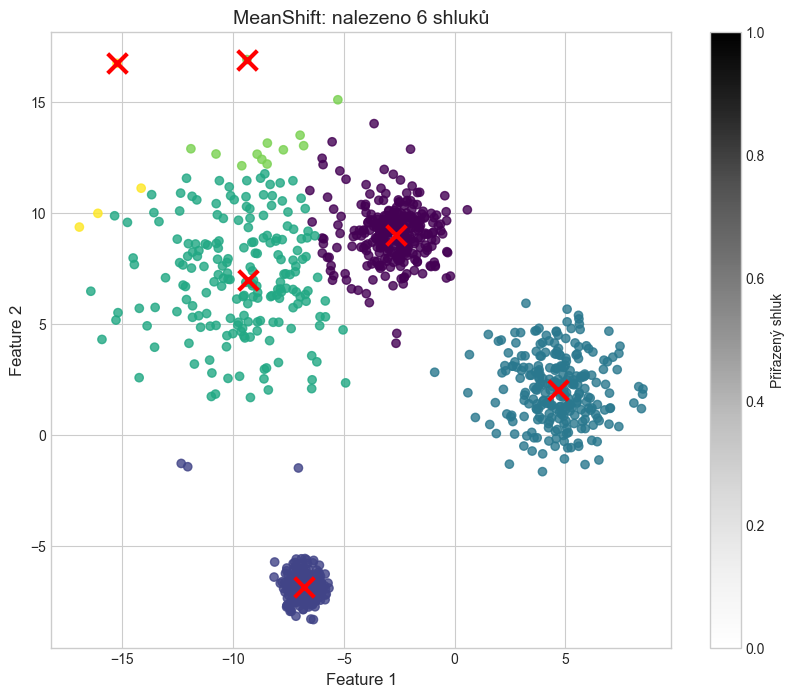

In [3]:
# Odhad vhodné šířky pásma (bandwidth) pomocí scikit-learn
bandwidth = estimate_bandwidth(X, quantile=0.2, n_samples=n_samples)
print(f"Odhadnutá šířka pásma (bandwidth): {bandwidth:.3f}")

# Aplikace MeanShift s odhadnutou šířkou pásma
start_time = time.time()
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms.fit(X)
end_time = time.time()

# Získání labelů (přiřazení do shluků) a center
labels = ms.labels_
cluster_centers = ms.cluster_centers_
n_clusters = len(np.unique(labels))

print(f"Počet nalezených shluků: {n_clusters}")
print(f"Doba výpočtu: {end_time - start_time:.3f} sekund")

# Vykreslení výsledků MeanShift
plt.figure(figsize=(10, 8))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.8)
plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1], 
           c='red', s=200, marker='x', linewidths=3)

plt.title(f'MeanShift: nalezeno {n_clusters} shluků', fontsize=14)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.grid(True)
plt.colorbar(label='Přiřazený shluk')
plt.show()

### Porovnání se skutečnými shluky a výpočet metrik kvality

Silhouette skóre: 0.665
Adjusted Rand Index: 0.879


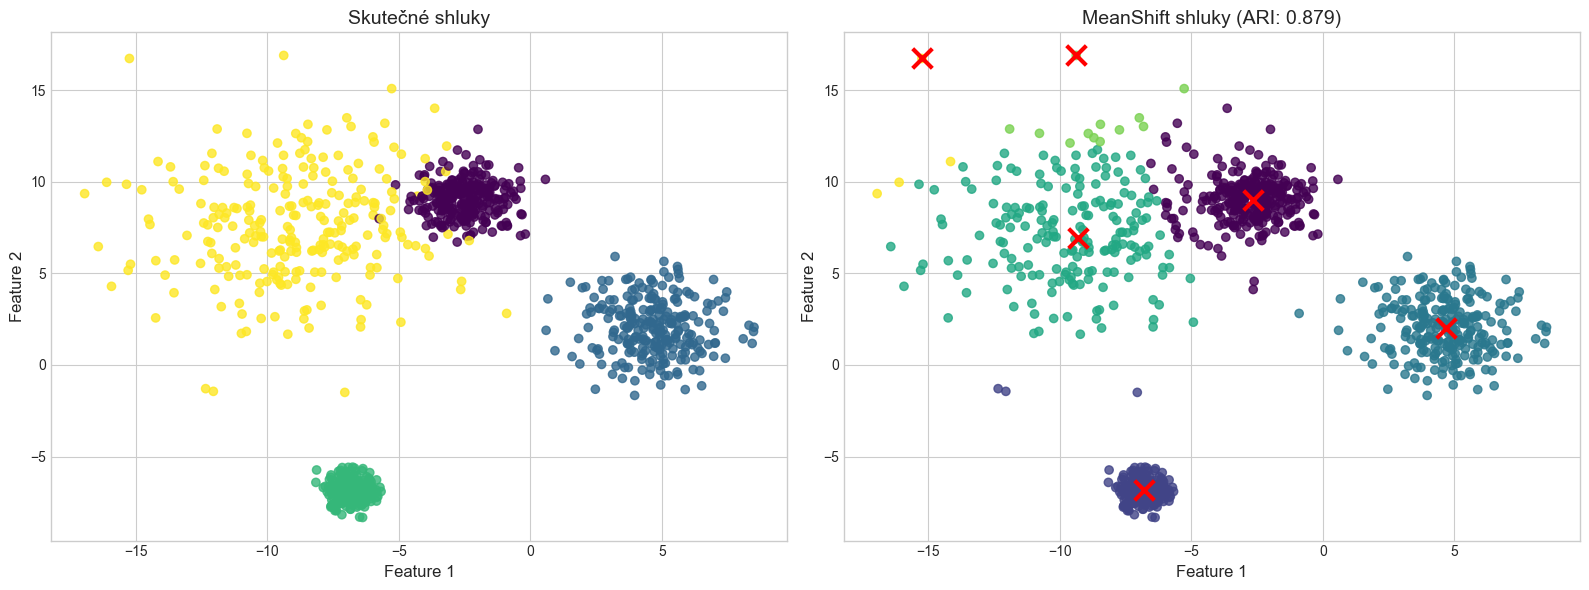

In [4]:
# Výpočet metrik
silhouette = silhouette_score(X, labels)
ari = adjusted_rand_score(y_true, labels)

print(f"Silhouette skóre: {silhouette:.3f}")
print(f"Adjusted Rand Index: {ari:.3f}")

# Porovnání výsledků MeanShift se skutečnými shluky
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Skutečné shluky
axes[0].scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', alpha=0.8)
axes[0].set_title('Skutečné shluky', fontsize=14)
axes[0].set_xlabel('Feature 1', fontsize=12)
axes[0].set_ylabel('Feature 2', fontsize=12)
axes[0].grid(True)

# MeanShift shluky
axes[1].scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.8)
axes[1].scatter(cluster_centers[:, 0], cluster_centers[:, 1], 
               c='red', s=200, marker='x', linewidths=3)
axes[1].set_title(f'MeanShift shluky (ARI: {ari:.3f})', fontsize=14)
axes[1].set_xlabel('Feature 1', fontsize=12)
axes[1].set_ylabel('Feature 2', fontsize=12)
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 2. Vliv parametru bandwidth (šířka pásma)

Šířka pásma je klíčovým parametrem, který určuje dosah hledání pro každý bod. Větší hodnoty vedou k menšímu počtu větších shluků, zatímco menší hodnoty vedou k více menším shlukům.

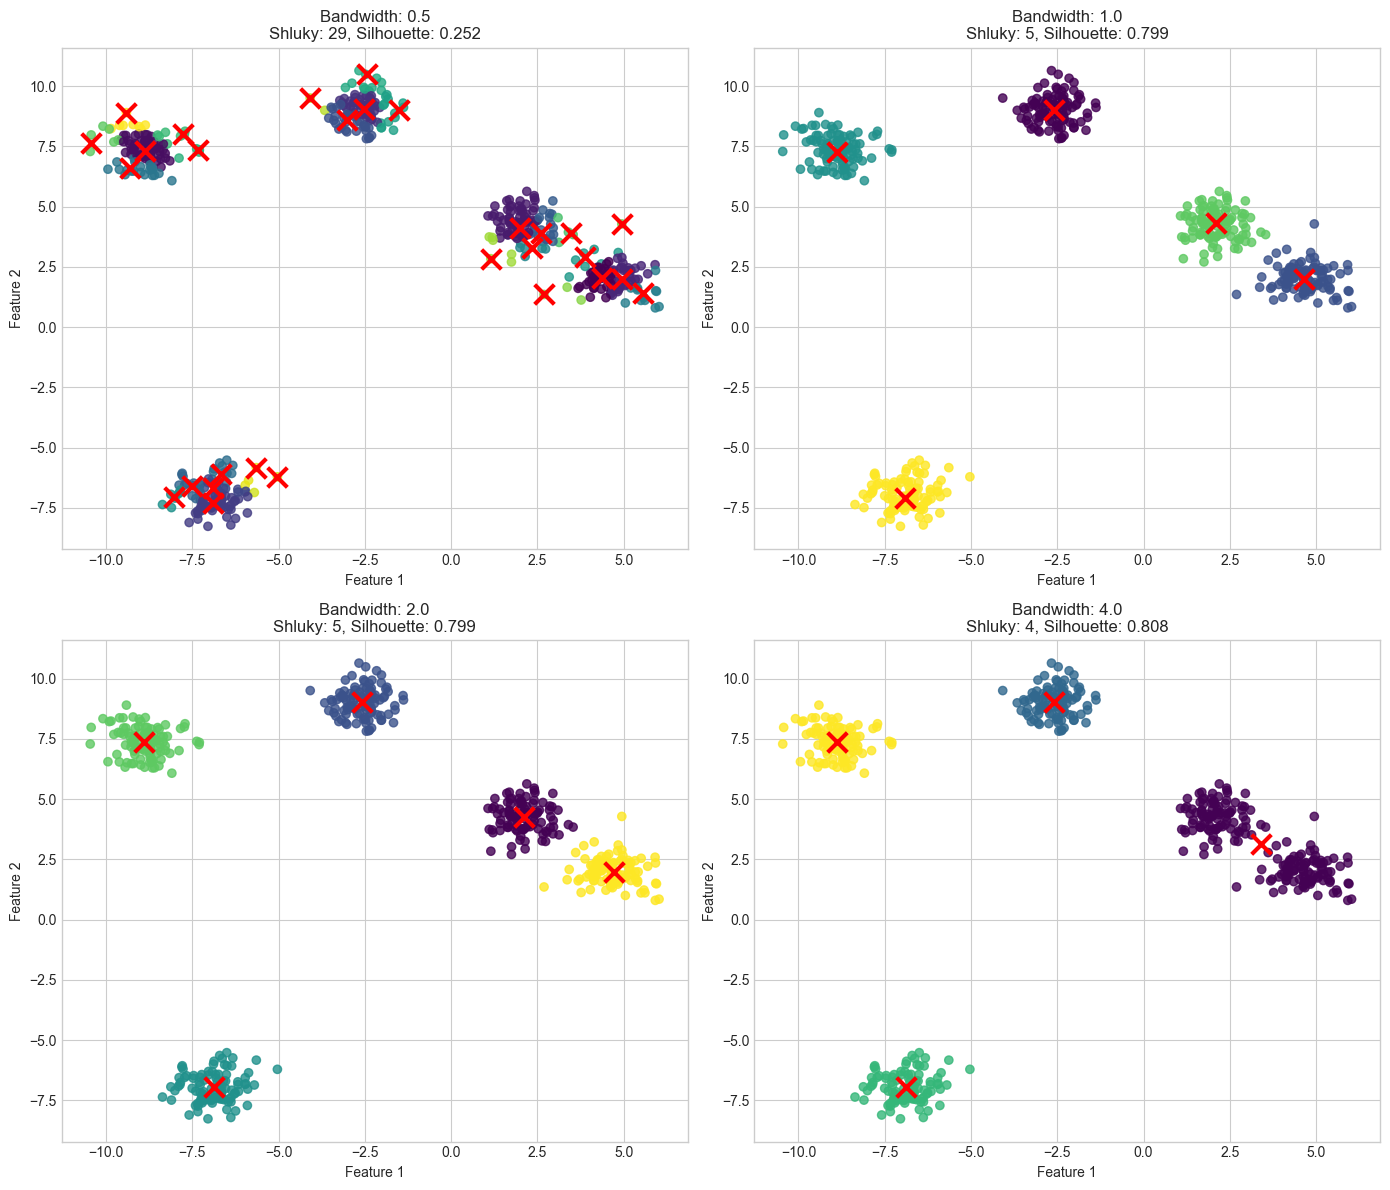

In [5]:
# Vytvoření dat s výraznějšími shluky pro lepší demonstraci
X_clear, y_clear = make_blobs(n_samples=500, centers=5, cluster_std=0.6, random_state=42)

# Různé hodnoty šířky pásma (bandwidth)
bandwidths = [0.5, 1.0, 2.0, 4.0]
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, bandwidth in enumerate(bandwidths):
    # Aplikace MeanShift s danou šířkou pásma
    ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
    ms.fit(X_clear)
    labels = ms.labels_
    centers = ms.cluster_centers_
    n_clusters = len(np.unique(labels))
    
    # Výpočet silhouette skóre
    if n_clusters > 1:  # Silhouette lze počítat jen pro více než jeden shluk
        silhouette = silhouette_score(X_clear, labels)
    else:
        silhouette = 0
    
    # Vykreslení výsledků
    axes[i].scatter(X_clear[:, 0], X_clear[:, 1], c=labels, cmap='viridis', alpha=0.8)
    axes[i].scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='x', linewidths=3)
    axes[i].set_title(f'Bandwidth: {bandwidth}\nShluky: {n_clusters}, Silhouette: {silhouette:.3f}', fontsize=12)
    axes[i].set_xlabel('Feature 1', fontsize=10)
    axes[i].set_ylabel('Feature 2', fontsize=10)
    axes[i].grid(True)

plt.tight_layout()
plt.show()

## 3. Automatické určení optimální šířky pásma

Funkce `estimate_bandwidth` používá heuristiku založenou na k-nejbližších sousedech k odhadu vhodné šířky pásma. Podíváme se na vliv parametru `quantile` na tento odhad.

Vliv parametru quantile na odhad bandwidth a výsledky MeanShift:


,Quantile,Bandwidth,Počet shluků,Silhouette skóre,ARI
0,0.1,2.083040,14,0.566572,0.823119
1,0.2,3.233332,6,0.664917,0.879090
2,0.3,8.342921,2,0.562165,0.324236
3,0.5,11.587216,1,0.000000,0.000000


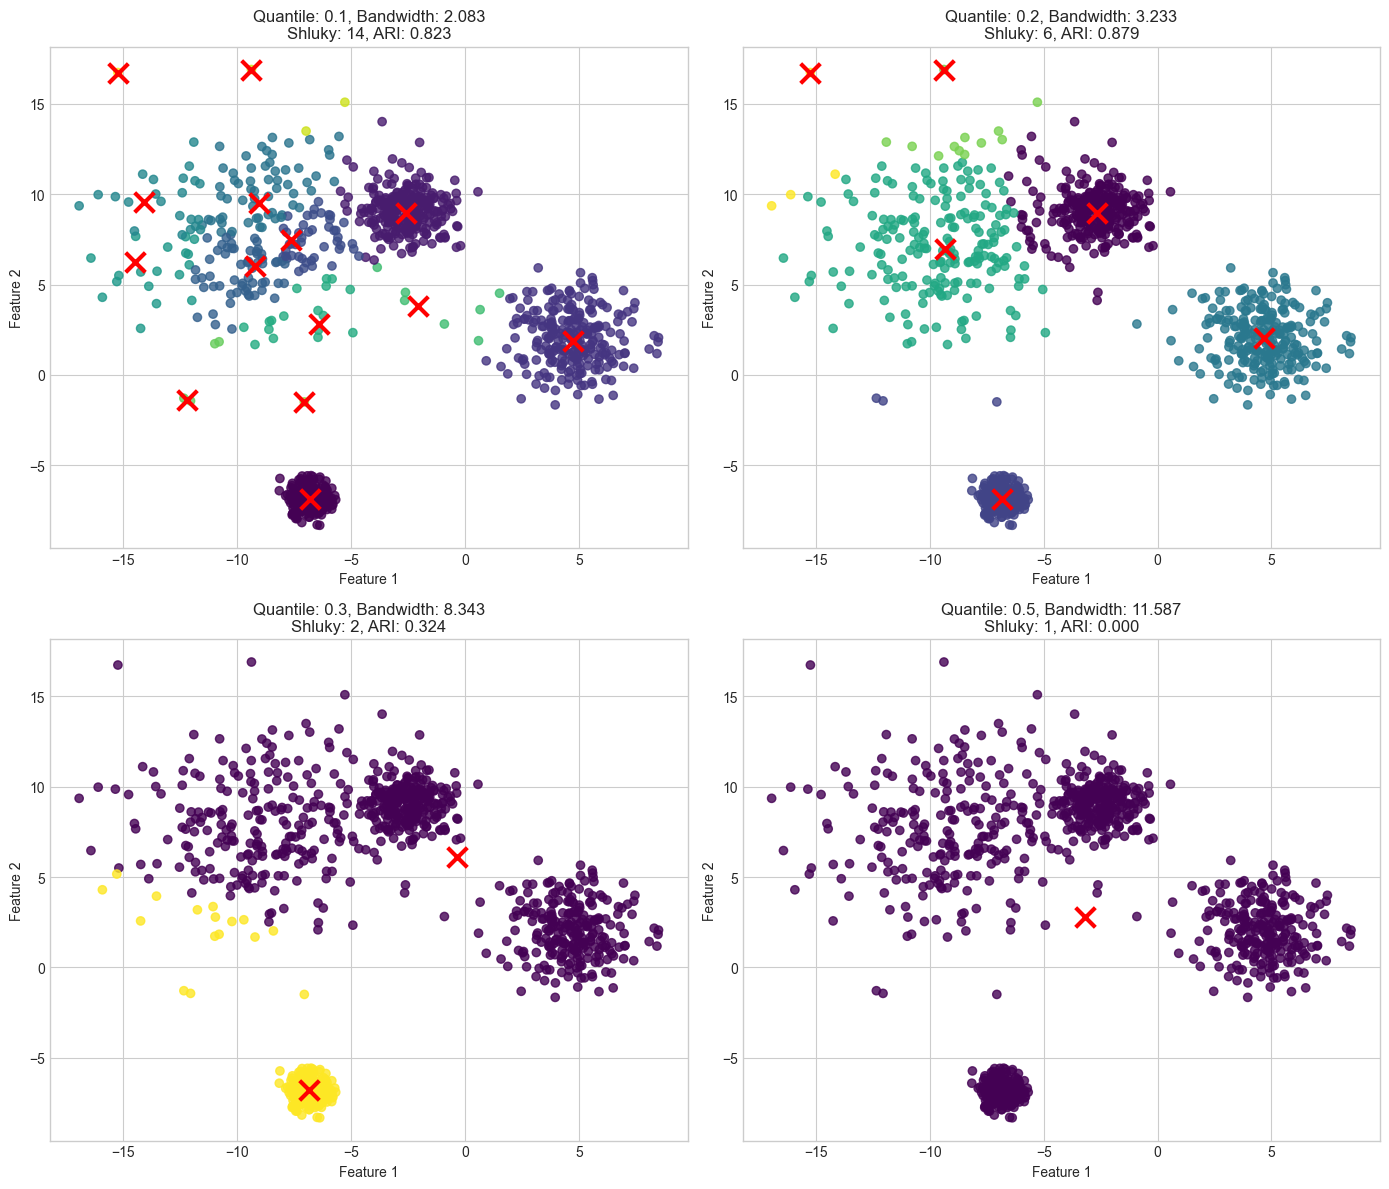

In [6]:
# Různé hodnoty quantile pro odhad bandwidth
quantiles = [0.1, 0.2, 0.3, 0.5]
bandwidths = []
n_clusters_list = []
silhouette_scores = []
ari_scores = []

# Procházíme různé hodnoty quantile
for q in quantiles:
    # Odhad bandwidth
    bandwidth = estimate_bandwidth(X, quantile=q, n_samples=n_samples)
    bandwidths.append(bandwidth)
    
    # Aplikace MeanShift
    ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
    ms.fit(X)
    labels = ms.labels_
    n_clusters = len(np.unique(labels))
    n_clusters_list.append(n_clusters)
    
    # Výpočet metrik
    if n_clusters > 1:
        silhouette_scores.append(silhouette_score(X, labels))
        ari_scores.append(adjusted_rand_score(y_true, labels))
    else:
        silhouette_scores.append(0)
        ari_scores.append(0)

# Vytvoření DataFrame pro přehledné zobrazení výsledků
results = pd.DataFrame({
    'Quantile': quantiles,
    'Bandwidth': bandwidths,
    'Počet shluků': n_clusters_list,
    'Silhouette skóre': silhouette_scores,
    'ARI': ari_scores
})

print("Vliv parametru quantile na odhad bandwidth a výsledky MeanShift:")
display(results)

# Vizualizace výsledků pro různé hodnoty quantile
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, q in enumerate(quantiles):
    bandwidth = bandwidths[i]
    ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
    ms.fit(X)
    labels = ms.labels_
    centers = ms.cluster_centers_
    n_clusters = len(np.unique(labels))
    
    axes[i].scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.8)
    axes[i].scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='x', linewidths=3)
    axes[i].set_title(f'Quantile: {q}, Bandwidth: {bandwidth:.3f}\nShluky: {n_clusters}, ARI: {ari_scores[i]:.3f}', fontsize=12)
    axes[i].set_xlabel('Feature 1', fontsize=10)
    axes[i].set_ylabel('Feature 2', fontsize=10)
    axes[i].grid(True)

plt.tight_layout()
plt.show()

## 4. Ruční implementace výpočtu optimálního bandwidth

Ukážeme si, jak funguje heuristika k-nejbližších sousedů pro výpočet bandwidth.

Ruční odhad bandwidth (quantile=0.2): 3.233
Scikit-learn odhad bandwidth (quantile=0.2): 3.233


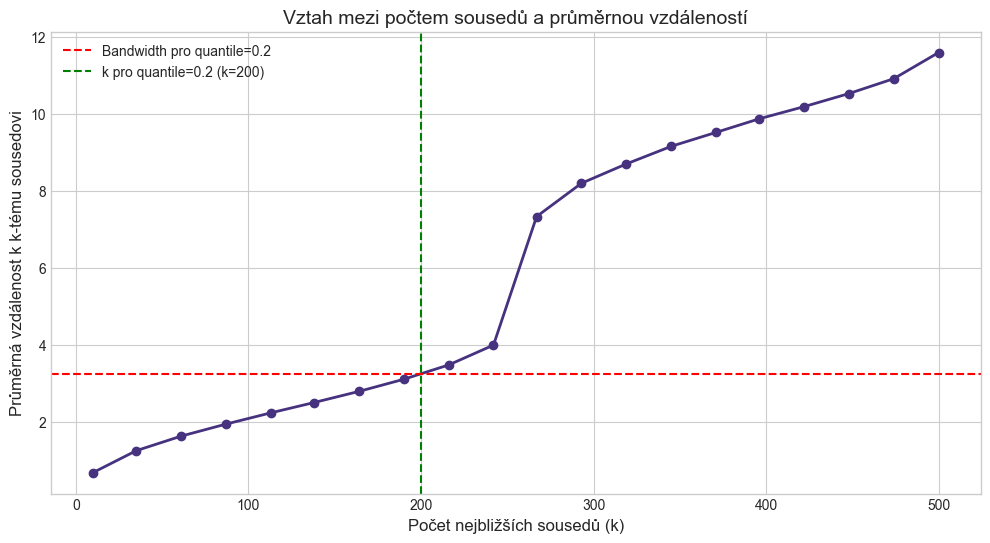

In [7]:
def manual_bandwidth_estimation(X, quantile=0.2, n_samples=None):
    """Ruční implementace odhadu bandwidth pomocí k-nejbližších sousedů"""
    if n_samples is not None:
        # Náhodný výběr n_samples bodů, pokud je dat moc
        idx = np.random.choice(X.shape[0], min(X.shape[0], n_samples), replace=False)
        X = X[idx]
    
    # Výpočet k jako kvantilu všech bodů
    k = int(X.shape[0] * quantile)
    k = max(k, 1)  # Zajištění, že k je aspoň 1
    
    # Nalezení k-nejbližších sousedů pro každý bod
    knn = NearestNeighbors(n_neighbors=k)
    knn.fit(X)
    distances, _ = knn.kneighbors(X)
    
    # Průměrná vzdálenost k k-tému nejbližšímu sousedovi
    bandwidth = np.mean(distances[:, -1])
    
    return bandwidth

# Porovnání ručně odhadnutého bandwidth s odhadem ze scikit-learn
quantile = 0.2
manual_bw = manual_bandwidth_estimation(X, quantile=quantile)
sklearn_bw = estimate_bandwidth(X, quantile=quantile)

print(f"Ruční odhad bandwidth (quantile={quantile}): {manual_bw:.3f}")
print(f"Scikit-learn odhad bandwidth (quantile={quantile}): {sklearn_bw:.3f}")

# Vizualizace průměrných vzdáleností k nejbližším sousedům
plt.figure(figsize=(12, 6))

# Výpočet průměrných vzdáleností pro různé hodnoty k
k_values = np.linspace(10, int(X.shape[0] * 0.5), 20).astype(int)
mean_distances = []

for k in k_values:
    knn = NearestNeighbors(n_neighbors=k)
    knn.fit(X)
    distances, _ = knn.kneighbors(X)
    mean_distances.append(np.mean(distances[:, -1]))

plt.plot(k_values, mean_distances, 'o-', linewidth=2)
plt.axhline(y=manual_bw, color='r', linestyle='--', label=f'Bandwidth pro quantile={quantile}')
plt.axvline(x=int(X.shape[0] * quantile), color='g', linestyle='--', 
           label=f'k pro quantile={quantile} (k={int(X.shape[0] * quantile)})')
plt.xlabel('Počet nejbližších sousedů (k)', fontsize=12)
plt.ylabel('Průměrná vzdálenost k k-tému sousedovi', fontsize=12)
plt.title('Vztah mezi počtem sousedů a průměrnou vzdáleností', fontsize=14)
plt.grid(True)
plt.legend()
plt.show()

## 5. Porovnání MeanShift s K-means

Porovnáme výkon MeanShift s K-means na různých typech dat.

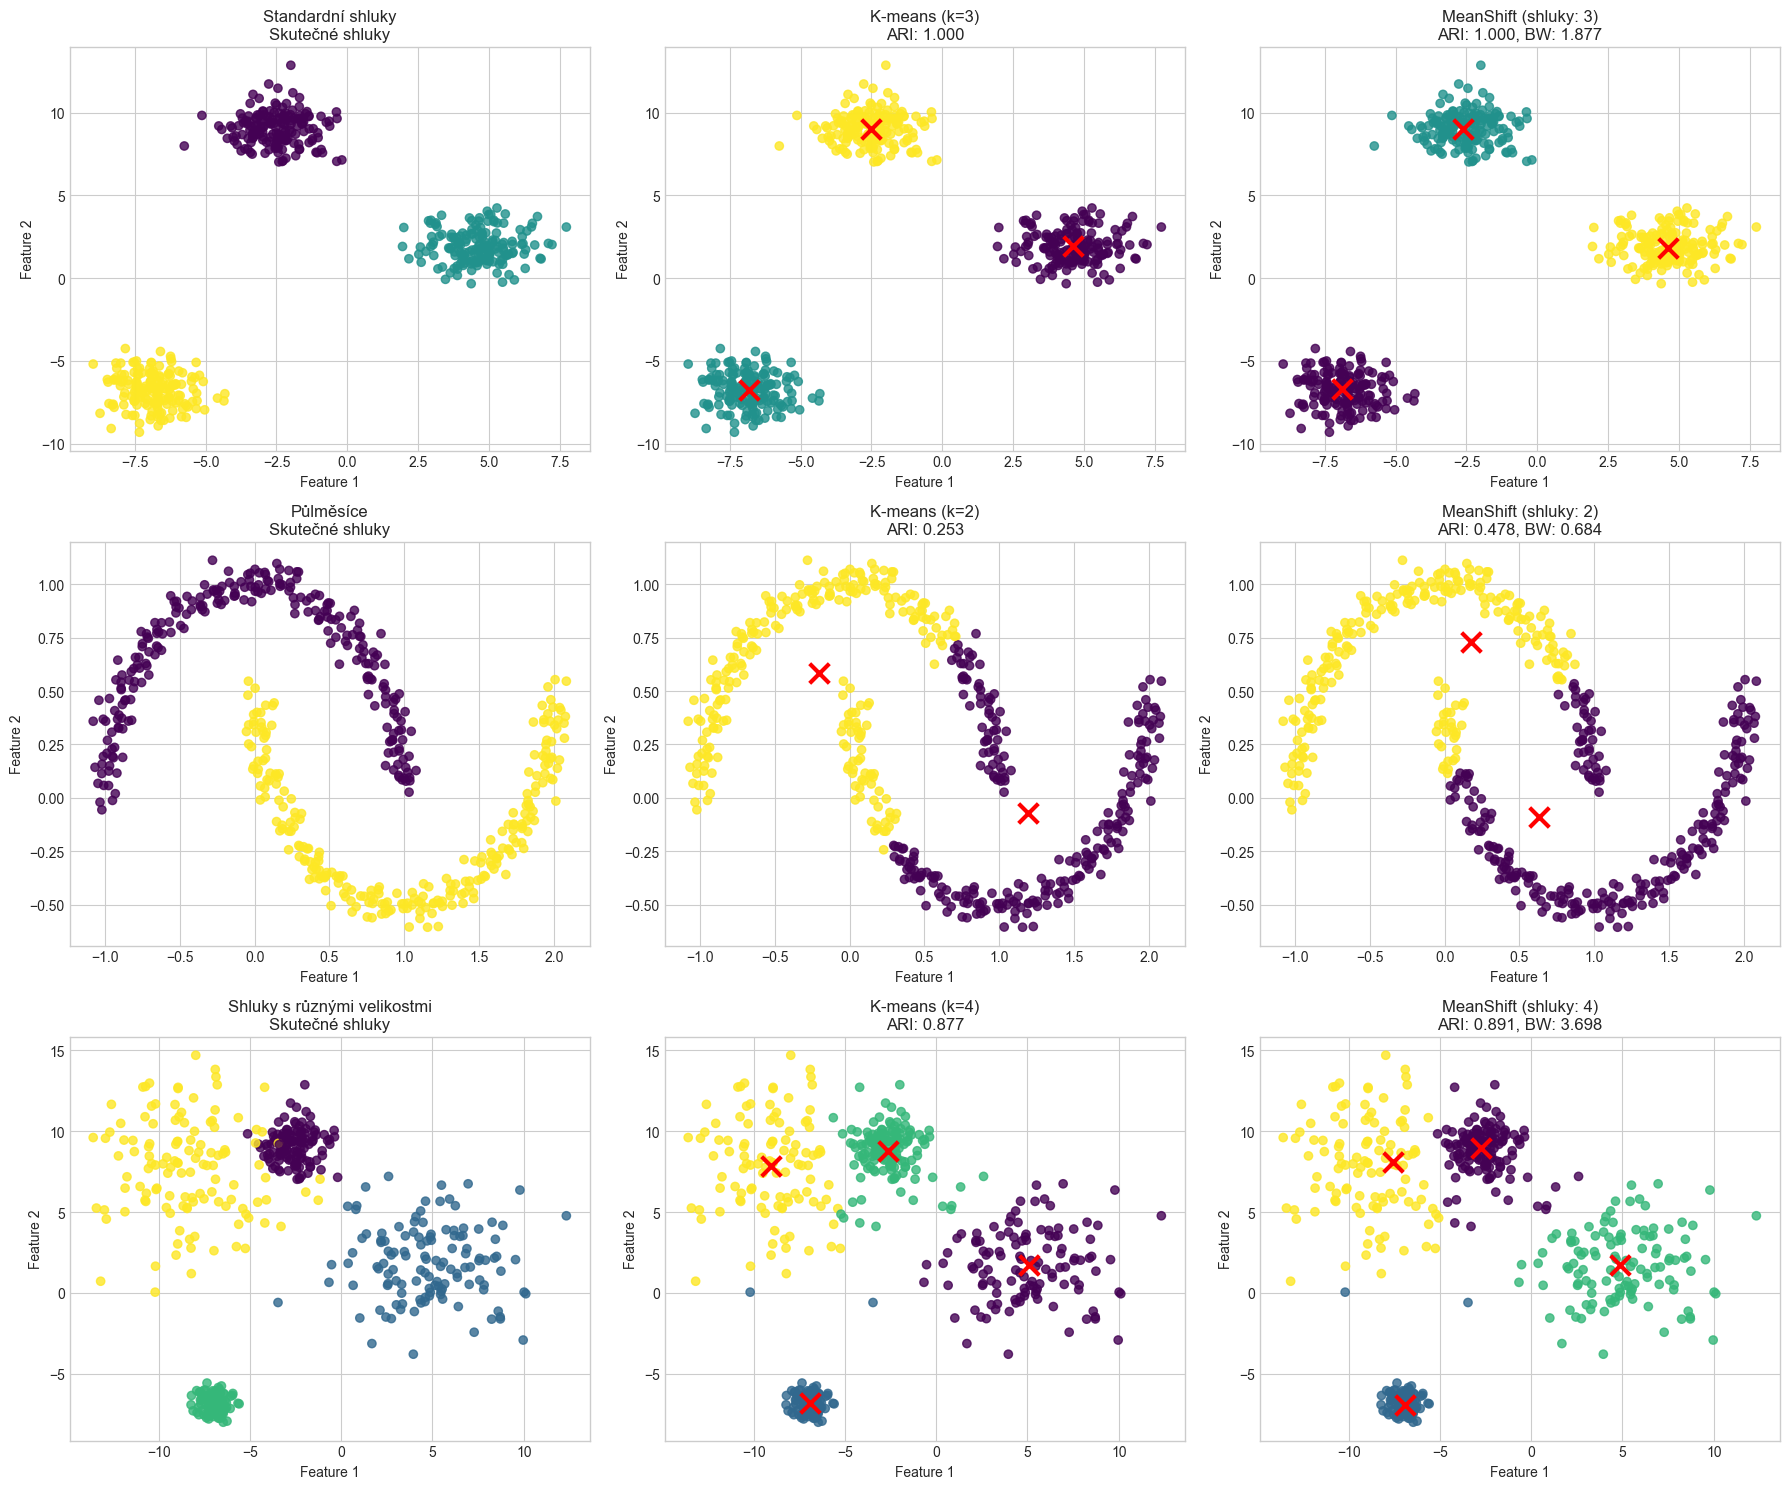

In [8]:
# Funkce pro vytvoření různých datových sad
def create_datasets():
    # 1. Standardní shluky (vhodné pro K-means)
    X1, y1 = make_blobs(n_samples=500, centers=3, random_state=42)
    
    # 2. Půlměsíce (nevhodné pro K-means)
    X2, y2 = make_moons(n_samples=500, noise=0.05, random_state=42)
    
    # 3. Shluky s různými velikostmi a hustotami
    X3, y3 = make_blobs(n_samples=500, centers=4, 
                      cluster_std=[1.0, 2.5, 0.5, 3.0],
                      random_state=42)
    
    return [(X1, y1, "Standardní shluky"), 
            (X2, y2, "Půlměsíce"),
            (X3, y3, "Shluky s různými velikostmi")]

# Vytvoření datových sad
datasets = create_datasets()

# Porovnání MeanShift a K-means na různých typech dat
fig, axes = plt.subplots(len(datasets), 3, figsize=(18, 15))

for i, (X, y_true, title) in enumerate(datasets):
    # Původní data
    axes[i, 0].scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', alpha=0.8)
    axes[i, 0].set_title(f'{title}\nSkutečné shluky', fontsize=12)
    axes[i, 0].set_xlabel('Feature 1', fontsize=10)
    axes[i, 0].set_ylabel('Feature 2', fontsize=10)
    axes[i, 0].grid(True)
    
    # K-means
    n_clusters = len(np.unique(y_true))
    km = KMeans(n_clusters=n_clusters, random_state=42)
    km_labels = km.fit_predict(X)
    km_ari = adjusted_rand_score(y_true, km_labels)
    
    axes[i, 1].scatter(X[:, 0], X[:, 1], c=km_labels, cmap='viridis', alpha=0.8)
    axes[i, 1].scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
                      c='red', s=200, marker='x', linewidths=3)
    axes[i, 1].set_title(f'K-means (k={n_clusters})\nARI: {km_ari:.3f}', fontsize=12)
    axes[i, 1].set_xlabel('Feature 1', fontsize=10)
    axes[i, 1].set_ylabel('Feature 2', fontsize=10)
    axes[i, 1].grid(True)
    
    # MeanShift
    bandwidth = estimate_bandwidth(X, quantile=0.2)
    ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
    ms_labels = ms.fit_predict(X)
    ms_centers = ms.cluster_centers_
    ms_n_clusters = len(np.unique(ms_labels))
    ms_ari = adjusted_rand_score(y_true, ms_labels)
    
    axes[i, 2].scatter(X[:, 0], X[:, 1], c=ms_labels, cmap='viridis', alpha=0.8)
    axes[i, 2].scatter(ms_centers[:, 0], ms_centers[:, 1],
                      c='red', s=200, marker='x', linewidths=3)
    axes[i, 2].set_title(f'MeanShift (shluky: {ms_n_clusters})\nARI: {ms_ari:.3f}, BW: {bandwidth:.3f}', fontsize=12)
    axes[i, 2].set_xlabel('Feature 1', fontsize=10)
    axes[i, 2].set_ylabel('Feature 2', fontsize=10)
    axes[i, 2].grid(True)

plt.tight_layout()
plt.show()

## 6. MeanShift na reálných datech

Nyní aplikujeme MeanShift na reálný dataset Iris.

In [9]:
# Načtení Iris datasetu
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Standardizace dat
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)

# Odhad bandwidth pro MeanShift
bandwidth_iris = estimate_bandwidth(X_iris_scaled, quantile=0.2)
print(f"Odhadnutý bandwidth pro Iris dataset: {bandwidth_iris:.3f}")

# Aplikace MeanShift
ms_iris = MeanShift(bandwidth=bandwidth_iris, bin_seeding=True)
t0 = time.time()
ms_labels = ms_iris.fit_predict(X_iris_scaled)
t_ms = time.time() - t0
ms_centers = ms_iris.cluster_centers_
ms_n_clusters = len(np.unique(ms_labels))

# Pro srovnání použijeme K-means
km_iris = KMeans(n_clusters=3, random_state=42)  # Víme, že Iris má 3 druhy
t0 = time.time()
km_labels = km_iris.fit_predict(X_iris_scaled)
t_km = time.time() - t0

# Výpočet metrik
ms_silhouette = silhouette_score(X_iris_scaled, ms_labels)
km_silhouette = silhouette_score(X_iris_scaled, km_labels)
ms_ari = adjusted_rand_score(y_iris, ms_labels)
km_ari = adjusted_rand_score(y_iris, km_labels)

print(f"MeanShift - počet shluků: {ms_n_clusters}, čas: {t_ms:.3f}s, ARI: {ms_ari:.3f}, Silhouette: {ms_silhouette:.3f}")
print(f"K-means - počet shluků: 3, čas: {t_km:.3f}s, ARI: {km_ari:.3f}, Silhouette: {km_silhouette:.3f}")

Odhadnutý bandwidth pro Iris dataset: 1.207
MeanShift - počet shluků: 3, čas: 0.228s, ARI: 0.560, Silhouette: 0.433
K-means - počet shluků: 3, čas: 0.003s, ARI: 0.433, Silhouette: 0.480


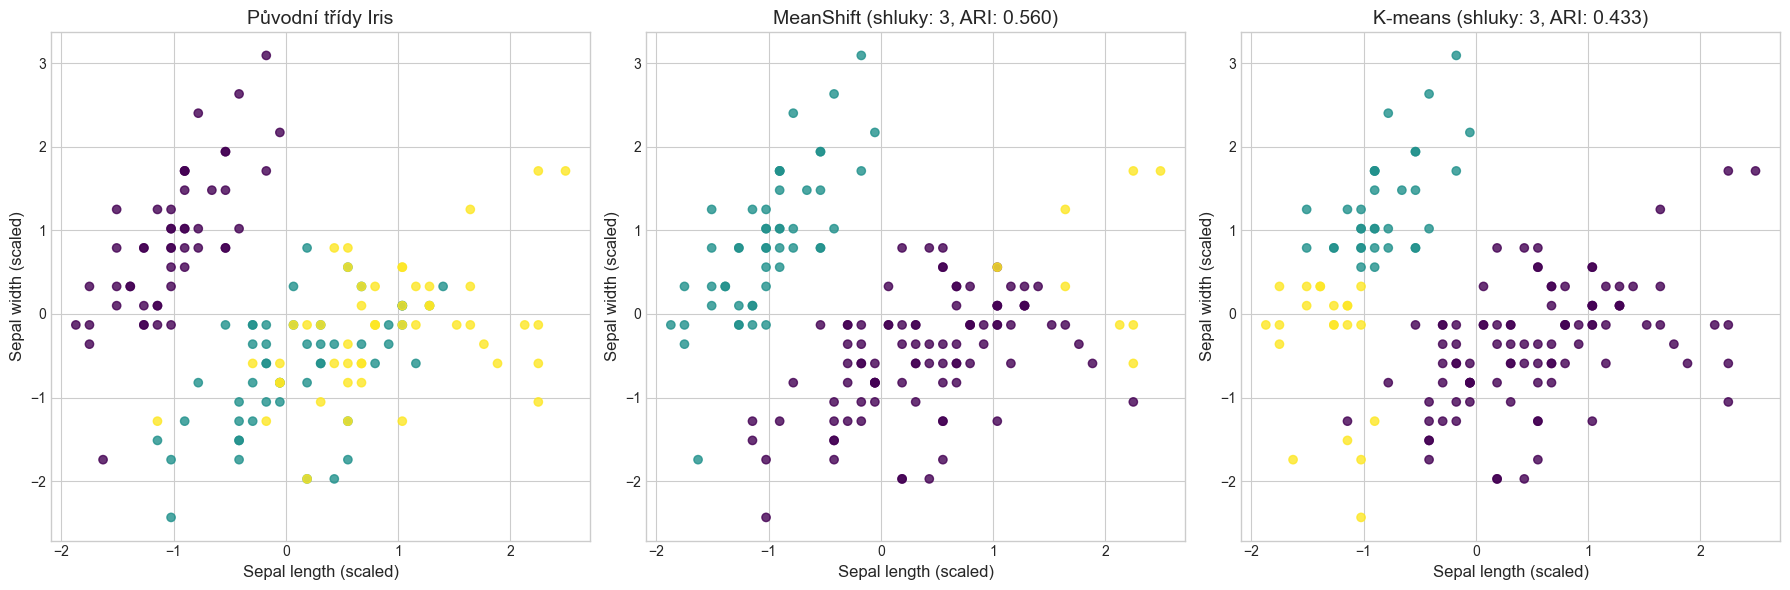

In [10]:
# Vizualizace výsledků pomocí prvních dvou příznaků
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Původní třídy Iris
axes[0].scatter(X_iris_scaled[:, 0], X_iris_scaled[:, 1], c=y_iris, cmap='viridis', alpha=0.8)
axes[0].set_title('Původní třídy Iris', fontsize=14)
axes[0].set_xlabel('Sepal length (scaled)', fontsize=12)
axes[0].set_ylabel('Sepal width (scaled)', fontsize=12)
axes[0].grid(True)

# MeanShift clustery
axes[1].scatter(X_iris_scaled[:, 0], X_iris_scaled[:, 1], c=ms_labels, cmap='viridis', alpha=0.8)
axes[1].set_title(f'MeanShift (shluky: {ms_n_clusters}, ARI: {ms_ari:.3f})', fontsize=14)
axes[1].set_xlabel('Sepal length (scaled)', fontsize=12)
axes[1].set_ylabel('Sepal width (scaled)', fontsize=12)
axes[1].grid(True)

# K-means clustery
axes[2].scatter(X_iris_scaled[:, 0], X_iris_scaled[:, 1], c=km_labels, cmap='viridis', alpha=0.8)
axes[2].set_title(f'K-means (shluky: 3, ARI: {km_ari:.3f})', fontsize=14)
axes[2].set_xlabel('Sepal length (scaled)', fontsize=12)
axes[2].set_ylabel('Sepal width (scaled)', fontsize=12)
axes[2].grid(True)

plt.tight_layout()
plt.show()

## 7. Implementace MeanShift od základů

Pro lepší pochopení algoritmu implementujeme základní verzi MeanShift bez použití scikit-learn.

In [11]:
def gaussian_kernel(distance, bandwidth):
    """Gaussovská jádrová funkce"""
    return np.exp(-0.5 * (distance / bandwidth) ** 2) / (bandwidth * np.sqrt(2 * np.pi))

def meanshift_step(X, current_point, bandwidth):
    """Jeden krok MeanShift algoritmu"""
    # Výpočet vzdáleností od aktuálního bodu ke všem bodům
    distances = np.linalg.norm(X - current_point, axis=1)
    
    # Aplikace jádrové funkce na vzdálenosti
    weights = gaussian_kernel(distances, bandwidth)
    
    # Výpočet vážené průměrné pozice
    shifted_point = np.sum(weights[:, np.newaxis] * X, axis=0) / np.sum(weights)
    
    return shifted_point

def meanshift(X, bandwidth, max_iter=100, tolerance=1e-3):
    """Implementace MeanShift algoritmu"""
    shifted_points = np.array(X)
    
    # Deklarace pole pro konvergované body
    converged = np.zeros(X.shape[0], dtype=bool)
    
    # Iterace pro každý bod
    for i in range(max_iter):
        print(f"Iterace {i+1}/{max_iter}", end='\r')
        
        # Kopie předchozích pozic pro kontrolu konvergence
        prev_positions = shifted_points.copy()
        
        # Posun každého bodu, který ještě nekonvergoval
        for j in range(X.shape[0]):
            if not converged[j]:
                shifted_points[j] = meanshift_step(X, shifted_points[j], bandwidth)
                
        # Kontrola konvergence
        shift_distances = np.linalg.norm(shifted_points - prev_positions, axis=1)
        converged = np.logical_or(converged, shift_distances < tolerance)
        
        # Pokud všechny body konvergovaly, končíme
        if np.all(converged):
            print(f"\nVšechny body konvergovaly po {i+1} iteracích")
            break
            
    # Identifikace unikátních clusterů (s tolerancí)
    cluster_centers = []
    labels = np.zeros(X.shape[0], dtype=int)
    
    for i, point in enumerate(shifted_points):
        # Kontrola, zda bod může být přiřazen k existujícímu shluku
        for j, center in enumerate(cluster_centers):
            if np.linalg.norm(point - center) < bandwidth * 0.5:  # Tolerance pro slučování
                labels[i] = j
                break
        else:  # Pokud se nenašel blízký shluk, vytvořit nový
            labels[i] = len(cluster_centers)
            cluster_centers.append(point)
    
    return np.array(cluster_centers), labels, shifted_points

Odhadnutý bandwidth: 1.065
Iterace 7/100
Všechny body konvergovaly po 7 iteracích
Počet nalezených shluků: 3
Doba výpočtu vlastní implementace: 0.046s
Počet shluků nalezených scikit-learn: 3
Doba výpočtu scikit-learn: 0.265s


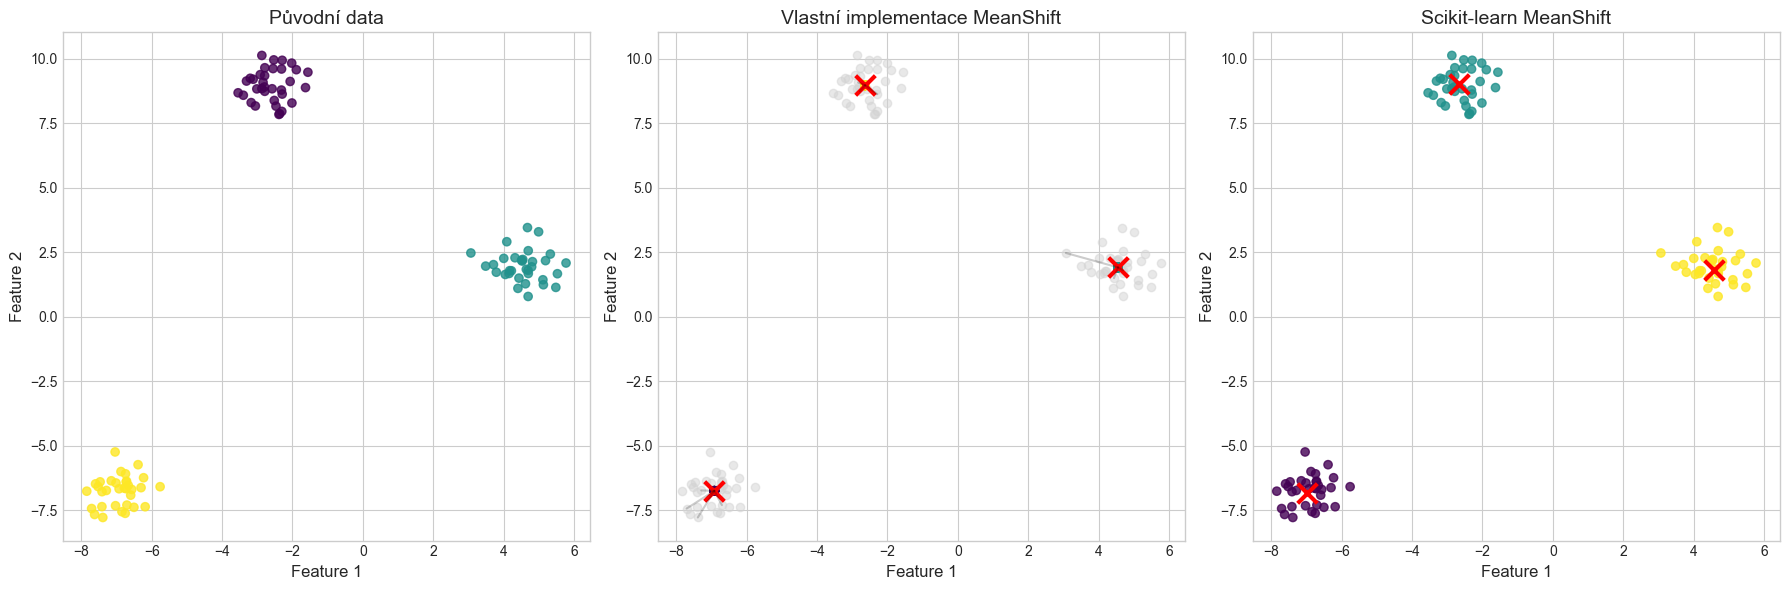

In [12]:
# Vytvoření jednoduchých dat pro ukázku
X_simple, y_simple = make_blobs(n_samples=100, centers=3, random_state=42, cluster_std=0.6)

# Odhad vhodného bandwidth
bandwidth_simple = estimate_bandwidth(X_simple, quantile=0.2)
print(f"Odhadnutý bandwidth: {bandwidth_simple:.3f}")

# Aplikace naší implementace MeanShift
t0 = time.time()
centers, labels, shifted_points = meanshift(X_simple, bandwidth_simple)
t_custom = time.time() - t0

print(f"Počet nalezených shluků: {len(centers)}")
print(f"Doba výpočtu vlastní implementace: {t_custom:.3f}s")

# Pro srovnání použijeme scikit-learn implementaci
t0 = time.time()
ms_sklearn = MeanShift(bandwidth=bandwidth_simple)
ms_sklearn.fit(X_simple)
t_sklearn = time.time() - t0

print(f"Počet shluků nalezených scikit-learn: {len(ms_sklearn.cluster_centers_)}")
print(f"Doba výpočtu scikit-learn: {t_sklearn:.3f}s")

# Vizualizace výsledků
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Původní data
axes[0].scatter(X_simple[:, 0], X_simple[:, 1], c=y_simple, cmap='viridis', alpha=0.8)
axes[0].set_title('Původní data', fontsize=14)
axes[0].set_xlabel('Feature 1', fontsize=12)
axes[0].set_ylabel('Feature 2', fontsize=12)
axes[0].grid(True)

# Cesty konvergence bodů
axes[1].scatter(X_simple[:, 0], X_simple[:, 1], c='lightgray', alpha=0.5)
axes[1].scatter(shifted_points[:, 0], shifted_points[:, 1], c=labels, cmap='viridis', alpha=0.8)
axes[1].scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='x', linewidths=3)

# Vykreslení cest konvergence pro několik vybraných bodů
for i in range(0, len(X_simple), 10):  # Vybere každý 10. bod pro přehlednost
    axes[1].plot([X_simple[i, 0], shifted_points[i, 0]], 
                [X_simple[i, 1], shifted_points[i, 1]], 
                'k-', alpha=0.2)

axes[1].set_title('Vlastní implementace MeanShift', fontsize=14)
axes[1].set_xlabel('Feature 1', fontsize=12)
axes[1].set_ylabel('Feature 2', fontsize=12)
axes[1].grid(True)

# Scikit-learn implementace
axes[2].scatter(X_simple[:, 0], X_simple[:, 1], c=ms_sklearn.labels_, cmap='viridis', alpha=0.8)
axes[2].scatter(ms_sklearn.cluster_centers_[:, 0], ms_sklearn.cluster_centers_[:, 1], 
               c='red', s=200, marker='x', linewidths=3)
axes[2].set_title('Scikit-learn MeanShift', fontsize=14)
axes[2].set_xlabel('Feature 1', fontsize=12)
axes[2].set_ylabel('Feature 2', fontsize=12)
axes[2].grid(True)

plt.tight_layout()
plt.show()

## 8. MeanShift pro segmentaci obrazu

MeanShift je často používán pro segmentaci obrazů. Ukážeme si jednoduchý příklad.

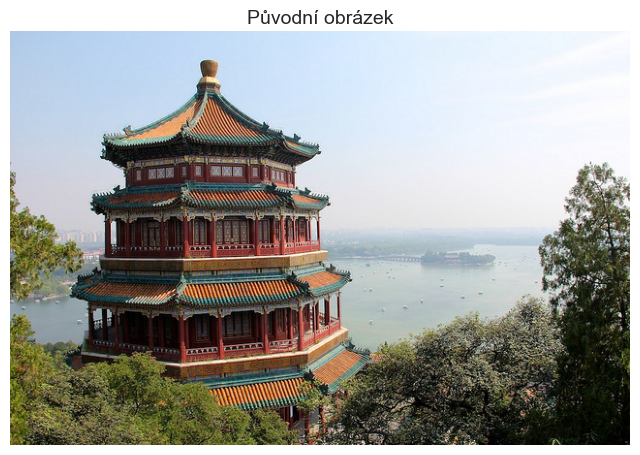

Odhadnutý bandwidth pro obrázek: 0.208
MeanShift nalezl 2 barevných shluků
Doba výpočtu: 1.418s
Segmentace celého obrázku...
Segmentace dokončena za 0.024s


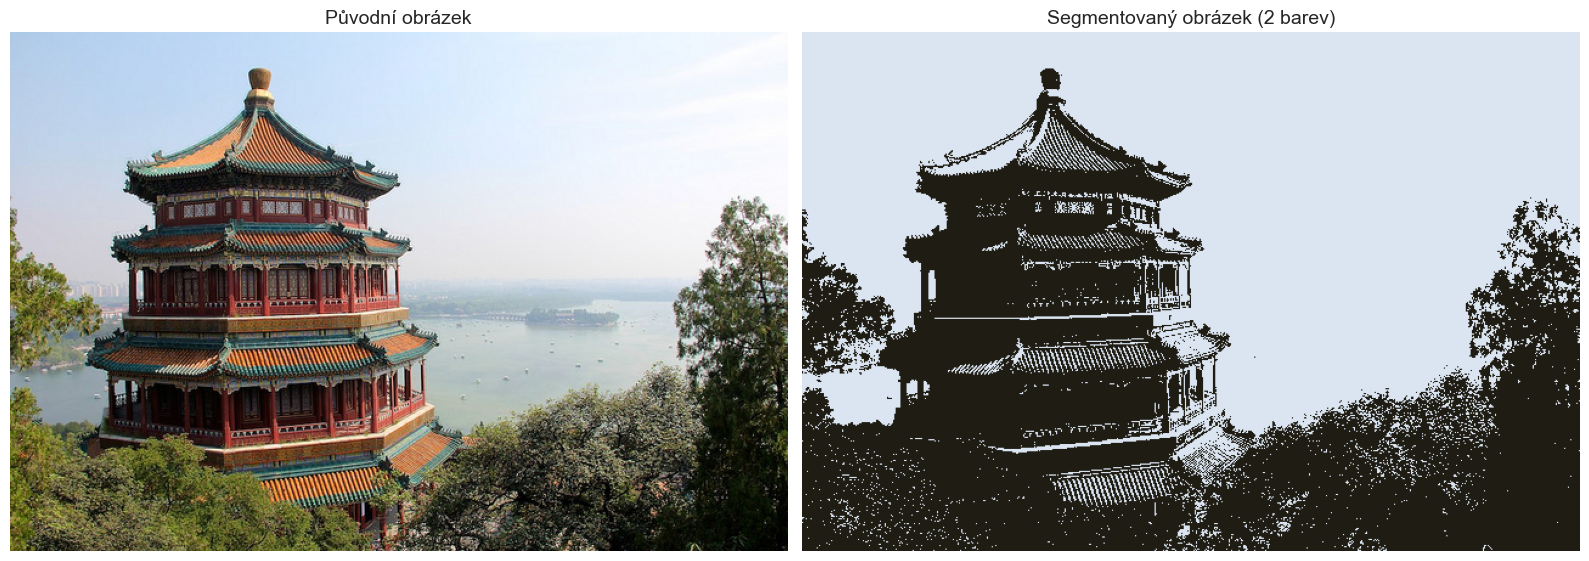

In [13]:
import matplotlib.image as mpimg
from sklearn.utils import shuffle

# Načtení ukázkového obrázku (můžete použít vlastní)
try:
    from sklearn.datasets import load_sample_image
    img = load_sample_image('china.jpg')
except:
    # Pokud není dostupný, vytvoříme náhodný obrázek
    img = np.random.randint(0, 255, (350, 450, 3), dtype=np.uint8)

# Zobrazení původního obrázku
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.title('Původní obrázek', fontsize=14)
plt.axis('off')
plt.show()

# Převod obrázku na pole pixelů (každý pixel je bod ve 3D RGB prostoru)
h, w, d = img.shape
image_array = img.reshape(h * w, d)

# Pro urychlení použijeme jen část pixelů (náhodný výběr)
n_samples = 10000
image_array_sample = shuffle(image_array, random_state=42)[:n_samples]

# Normalizace hodnot pixelů do rozsahu [0, 1]
image_array_sample = image_array_sample / 255.0

# Odhad bandwidth
bandwidth_img = estimate_bandwidth(image_array_sample, quantile=0.2, n_samples=500)
print(f"Odhadnutý bandwidth pro obrázek: {bandwidth_img:.3f}")

# Aplikace MeanShift
ms = MeanShift(bandwidth=bandwidth_img, bin_seeding=True)
t0 = time.time()
ms.fit(image_array_sample)
t_ms = time.time() - t0

print(f"MeanShift nalezl {len(ms.cluster_centers_)} barevných shluků")
print(f"Doba výpočtu: {t_ms:.3f}s")

# Mapování všech pixelů na nalezené shluky
# Pro velké obrázky je toto výpočetně náročné, proto segmentujeme postupně po částech
def segment_image(image_array, ms_model, batch_size=10000):
    labels = np.zeros(len(image_array), dtype=int)
    for i in range(0, len(image_array), batch_size):
        batch = image_array[i:min(i + batch_size, len(image_array))] / 255.0
        labels[i:min(i + batch_size, len(image_array))] = ms_model.predict(batch)
    return labels

# Segmentace celého obrázku
print("Segmentace celého obrázku...")
t0 = time.time()
labels = segment_image(image_array, ms)
t_segment = time.time() - t0
print(f"Segmentace dokončena za {t_segment:.3f}s")

# Vytvoření segmentovaného obrázku
segmented_image = np.zeros_like(image_array)
for i in range(len(ms.cluster_centers_)):
    segmented_image[labels == i] = ms.cluster_centers_[i] * 255

# Převod zpět na tvar obrázku
segmented_image = segmented_image.reshape(h, w, d).astype(np.uint8)

# Zobrazení výsledků
plt.figure(figsize=(16, 8))

plt.subplot(121)
plt.imshow(img)
plt.title('Původní obrázek', fontsize=14)
plt.axis('off')

plt.subplot(122)
plt.imshow(segmented_image)
plt.title(f'Segmentovaný obrázek ({len(ms.cluster_centers_)} barev)', fontsize=14)
plt.axis('off')

plt.tight_layout()
plt.show()

## 9. Shrnutí algoritmu MeanShift

### Výhody MeanShift:
1. **Automatické určení počtu shluků** - není třeba předem specifikovat počet shluků
2. **Flexibilita tvaru shluků** - schopnost detekovat shluky nepravidelných tvarů
3. **Založeno na hustotě** - přirozeně identifikuje oblasti s vysokou hustotou bodů
4. **Robustnost vůči odlehlým hodnotám** - odlehlé hodnoty většinou tvoří vlastní malé shluky
5. **Teoreticky podložený** - založen na konceptu odhadu hustoty jádra (kernel density estimation)

### Nevýhody MeanShift:
1. **Výpočetní náročnost** - algoritmická složitost O(n²), kde n je počet datových bodů
2. **Citlivost na parametr bandwidth** - výsledky silně závisí na zvolené šířce pásma
3. **Pomalý na velkých datových sadách** - pro velká data je potřeba použít optimalizace jako bin_seeding
4. **Obtížné určení optimálního bandwidth** - často vyžaduje experimentování s různými hodnotami
5. **Problémy s daty s různou hustotou** - jedna hodnota bandwidth nemusí být vhodná pro všechny oblasti dat

### Kdy použít MeanShift:
- Když předem neznáte počet shluků v datech
- Když očekáváte shluky nepravidelných tvarů nebo různých velikostí
- Pro segmentaci obrazu a zpracování počítačového vidění
- Když je důležitější kvalita shlukování než rychlost algoritmu
- Při relativně menších datových sadách (do cca 10 000 bodů bez optimalizací)

### Shrnutí parametrů scikit-learn implementace:
- **bandwidth** - šířka pásma určující dosah hledání pro každý bod (hlavní parametr)
- **seeds** - počáteční body pro shluky (obvykle automaticky určeno)
- **bin_seeding** - zda použít binning pro urychlení algoritmu (doporučeno pro větší datové sady)
- **min_bin_freq** - minimální počet bodů v binu pro generování seedů
- **cluster_all** - zda přiřadit všechny body ke shlukům nebo ponechat odlehlé hodnoty neoznačené
- **n_jobs** - počet paralelních jobů pro výpočet (urychlení na vícejádrových procesorech)